# Generation of Synthetic Dataset


## 1. imports


In [9]:

import pandas as pd
import matplotlib.pyplot as plt

## 2. Dataset

### 2.1 Real Apple TS

Lade Apple-Kursdaten von Yahoo Finance...

                Apple (AAPL) Tageskurse 2012–2026                
          (split-bereinigt, via Yahoo Finance, in USD)           
Datum            Kurs (USD)   Veränd. (%)    Veränd. (USD)
-----------------------------------------------------------------
2012-01-03     $     12.31         —               —
2012-01-04     $     12.38     +  0.54%       +$   0.07
2012-01-05     $     12.51     +  1.11%       +$   0.14
2012-01-06     $     12.64     +  1.05%       +$   0.13
2012-01-09     $     12.62       -0.16%       -$   0.02
2012-01-10     $     12.67     +  0.36%       +$   0.05
2012-01-11     $     12.65       -0.16%       -$   0.02
2012-01-12     $     12.61       -0.27%       -$   0.03
2012-01-13     $     12.57       -0.37%       -$   0.05
2012-01-17     $     12.71     +  1.16%       +$   0.15
2012-01-18     $     12.85     +  1.04%       +$   0.13
2012-01-19     $     12.80       -0.32%       -$   0.04
2012-01-20     $     12.58     

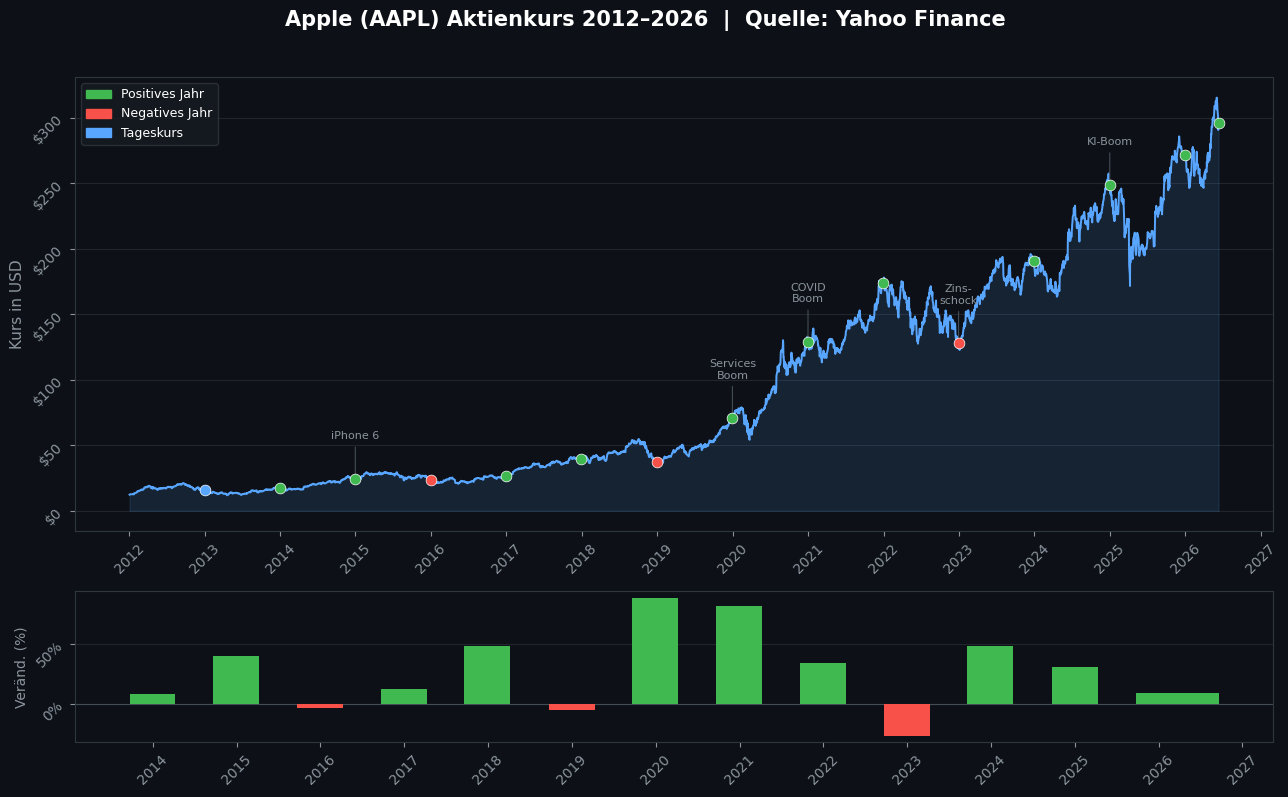

In [11]:
import yfinance as yf
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.dates as mdates

# ── Daten laden ──────────────────────────────────────────────────
print("Lade Apple-Kursdaten von Yahoo Finance...")
df = yf.download("AAPL", start="2012-01-01", end="2026-06-12", progress=False)
df = df[["Close"]].copy()
df.columns = ["Kurs"]
df.index = df.index.tz_localize(None)  # Zeitzone entfernen

# Jahresschlusskurse
jahres = df.resample("YE").last()
jahres.index = jahres.index.year

# ── Tagesweise Konsolenausgabe ───────────────────────────────────
print("\n" + "=" * 65)
print(f"{'Apple (AAPL) Tageskurse 2012–2026':^65}")
print(f"{'(split-bereinigt, via Yahoo Finance, in USD)':^65}")
print("=" * 65)
print(f"{'Datum':<14} {'Kurs (USD)':>12}   {'Veränd. (%)':<14} {'Veränd. (USD)'}")
print("-" * 65)

prev = None
for datum, row in df.iterrows():
    kurs = row["Kurs"]
    if prev is None:
        pct_str, abs_str = "      —", "       —"
    else:
        pct = (kurs - prev) / prev * 100
        absd = kurs - prev
        pct_str = f"  +{pct:6.2f}%" if pct >= 0 else f"  {pct:7.2f}%"
        abs_str = f"  +${absd:7.2f}" if absd >= 0 else f"  -${abs(absd):7.2f}"
    print(f"{str(datum.date()):<14} ${kurs:>10.2f}   {pct_str:<14} {abs_str}")
    prev = kurs

print("-" * 65)
gesamt = (df["Kurs"].iloc[-1] - df["Kurs"].iloc[0]) / df["Kurs"].iloc[0] * 100
print(f"{'Gesamtrendite:':<35} +{gesamt:.0f}%")
print(f"{'Aus $1.000 wurden:':<35} ${1000 * df['Kurs'].iloc[-1] / df['Kurs'].iloc[0]:,.0f}")
print("=" * 65)

# ── Jahresübersicht ──────────────────────────────────────────────
kurse_list = jahres["Kurs"].tolist()
jahre_list = jahres.index.tolist()

print("\n" + "=" * 55)
print(f"{'Jahresübersicht':^55}")
print("=" * 55)
print(f"{'Jahr':<8} {'Kurs (USD)':>12}   {'Veränd. (%)':<14} {'Trend'}")
print("-" * 55)
for i, (jahr, kurs) in enumerate(zip(jahre_list, kurse_list)):
    if i == 0:
        pct_str, trend = "      —", ""
    else:
        pct = (kurs - kurse_list[i - 1]) / kurse_list[i - 1] * 100
        pct_str = f"  +{pct:6.2f}%" if pct >= 0 else f"  {pct:7.2f}%"
        trend = "▲" * min(int(abs(pct) / 15) + 1, 5) if pct >= 0 else "▼"
    hinweis = " ← aktuell" if i == len(jahre_list) - 1 else ""
    print(f"{jahr:<8} ${kurs:>10.2f}   {pct_str:<14} {trend}{hinweis}")
print("=" * 55)

# ── Grafik ───────────────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(
    2, 1, figsize=(13, 8),
    gridspec_kw={"height_ratios": [3, 1]},
    facecolor="#0d1117"
)
fig.suptitle(
    "Apple (AAPL) Aktienkurs 2012–2026  |  Quelle: Yahoo Finance",
    color="white", fontsize=15, fontweight="bold", y=0.99
)

# Tageskurs-Linie
ax1.set_facecolor("#0d1117")
ax1.plot(df.index, df["Kurs"], color="#58a6ff", linewidth=1.4, zorder=3)
ax1.fill_between(df.index, df["Kurs"], alpha=0.12, color="#58a6ff", zorder=2)

# Jahrespunkte einfärben
for i, (jahr, kurs) in enumerate(zip(jahre_list, kurse_list)):
    if i == 0:
        farbe = "#58a6ff"
    else:
        farbe = "#3fb950" if kurs >= kurse_list[i - 1] else "#f85149"
    datum = df[df.index.year == jahr].index[-1]
    ax1.scatter(datum, kurs, color=farbe, s=60, zorder=4,
                edgecolors="white", linewidths=0.5)

# Ereignis-Annotationen
ereignisse = {
    2014: "iPhone 6",
    2019: "Services\nBoom",
    2020: "COVID\nBoom",
    2022: "Zins-\nschock",
    2024: "KI-Boom",
}
for jahr, label in ereignisse.items():
    kurs = jahres.loc[jahr, "Kurs"]
    datum = df[df.index.year == jahr].index[-1]
    ax1.annotate(
        label, xy=(datum, kurs), xytext=(datum, kurs + 30),
        fontsize=8, color="#8b949e", ha="center",
        arrowprops=dict(arrowstyle="-", color="#444c56", lw=0.8),
    )

ax1.set_ylabel("Kurs in USD", color="#8b949e", fontsize=11)
ax1.yaxis.set_major_formatter(mticker.FormatStrFormatter("$%.0f"))
ax1.xaxis.set_major_locator(mdates.YearLocator())
ax1.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax1.tick_params(colors="#8b949e", rotation=45)
for spine in ax1.spines.values():
    spine.set_edgecolor("#30363d")
ax1.grid(axis="y", color="#21262d", linewidth=0.8)
ax1.set_axisbelow(True)

# Balkendiagramm: jährliche Veränderung
ax2.set_facecolor("#0d1117")
farben, werte, positionen = [], [], []
for i in range(1, len(jahre_list)):
    pct = (kurse_list[i] - kurse_list[i - 1]) / kurse_list[i - 1] * 100
    datum = df[df.index.year == jahre_list[i]].index[-1]
    positionen.append(datum)
    werte.append(pct)
    farben.append("#3fb950" if pct >= 0 else "#f85149")

ax2.bar(positionen, werte, color=farben, width=200, zorder=3)
ax2.axhline(0, color="#444c56", linewidth=0.8)
ax2.set_ylabel("Veränd. (%)", color="#8b949e", fontsize=10)
ax2.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.0f%%"))
ax2.xaxis.set_major_locator(mdates.YearLocator())
ax2.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax2.tick_params(colors="#8b949e", rotation=45)
for spine in ax2.spines.values():
    spine.set_edgecolor("#30363d")
ax2.grid(axis="y", color="#21262d", linewidth=0.8)
ax2.set_axisbelow(True)

# Legende
from matplotlib.patches import Patch
ax1.legend(
    handles=[
        Patch(color="#3fb950", label="Positives Jahr"),
        Patch(color="#f85149", label="Negatives Jahr"),
        Patch(color="#58a6ff", label="Tageskurs"),
    ],
    loc="upper left", facecolor="#161b22",
    edgecolor="#30363d", labelcolor="white", fontsize=9
)

plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.savefig("apple_kurs_yfinance.png", dpi=150, bbox_inches="tight", facecolor="#0d1117")
print("\nGrafik gespeichert: apple_kurs_yfinance.png")
plt.show()

### 2.2 Synthetic Apple TS